<a href="https://colab.research.google.com/github/dudaoliani/MVP-CEP-Milk-Quality-Prediction/blob/main/Milk_Quality_Prediction_l_Vers%C3%A3o_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'milkquality' dataset.
--- Estatísticas Descritivas do Processo ---


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,0.546742,0.432483,0.671388,0.491029,251.840415
std,1.399679,10.098364,0.498046,0.495655,0.469930,0.500156,4.307424
min,3.000000,34.000000,0.000000,0.000000,0.000000,0.000000,240.000000
25%,6.500000,38.000000,0.000000,0.000000,0.000000,0.000000,250.000000
50%,6.700000,41.000000,1.000000,0.000000,1.000000,0.000000,255.000000
75%,6.800000,45.000000,1.000000,1.000000,1.000000,1.000000,255.000000
max,9.500000,90.000000,1.000000,1.000000,1.000000,1.000000,255.000000


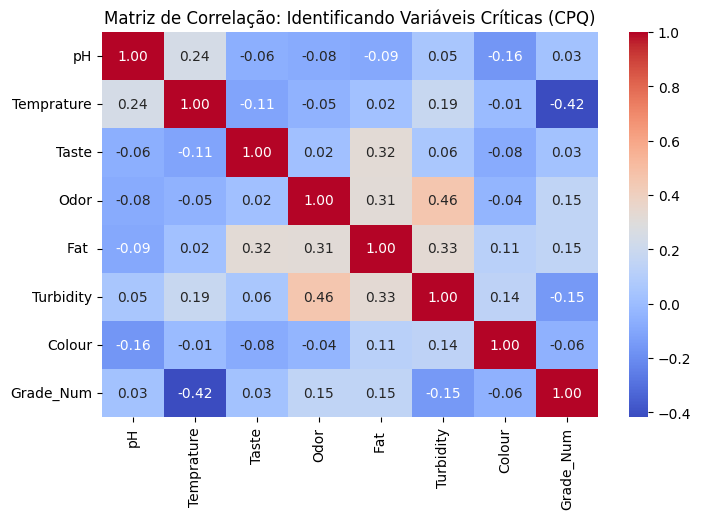


--- Relatório de Performance do Classificador ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        78
           1       1.00      1.00      1.00        86
           2       0.98      1.00      0.99        48

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212



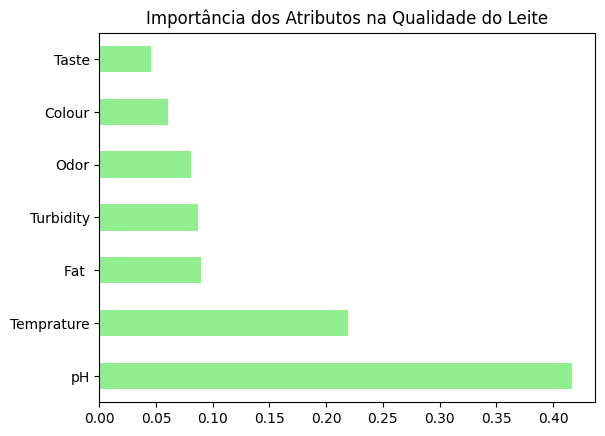


--- Parâmetros CEP ---
Linha Central (p-barra): 0.4048
ARL0 (Frequência esperada de alarmes falsos): 370 amostras


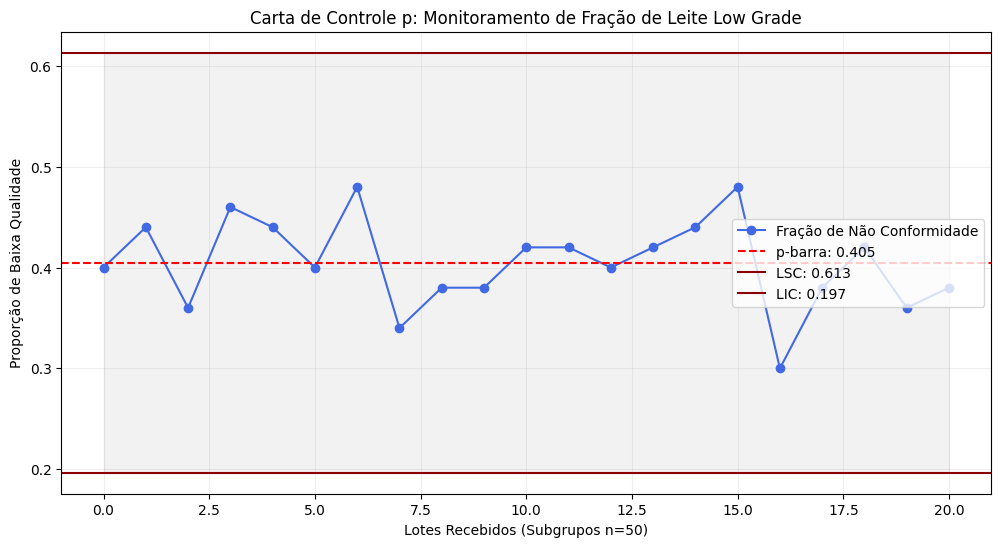

 PROCESSO ESTÁVEL: Variabilidade dentro do esperado por causas aleatórias.


In [14]:
# ==============================================================================
# MVP - CONTROLE ESTATÍSTICO DE PROCESSOS (CEP) - VERSÃO EXPANDIDA
# Aluna: Maria Eduarda Moreno Oliani
# Objetivo: Triagem Automática e Monitoramento de Qualidade do Leite Cru
# Base teórica: Montgomery, Atributos e Ciclo DMAMC
# ==============================================================================

# 1. DEFINIR E MEDIR (Carga e Análise Exploratória) [cite: 833, 851]
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Download e carga automática via kagglehub [cite: 1973]
path = kagglehub.dataset_download("cpluzshrijayan/milkquality")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("--- Estatísticas Descritivas do Processo ---")
display(df.describe()) # Caracterização estatística inicial [cite: 139]

# 2. ANALISAR (Tratamento e Correlações) [cite: 859]
# Mapeamento para análise numérica
grade_map = {'low': 0, 'medium': 1, 'high': 2}
df['Grade_Num'] = df['Grade'].map(grade_map)

# Verificando a hipótese da aluna: pH e Turbidez são os mais importantes?
# Corrigido para calcular a correlação apenas em colunas numéricas
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlação: Identificando Variáveis Críticas (CPQ)") # [cite: 446]
plt.show()

# 3. MELHORAR (Modelagem Preditiva) [cite: 868]
X = df.drop(['Grade', 'Grade_Num'], axis=1)
y = df['Grade_Num']

# Divisão Treino/Teste com semente fixa para reprodutibilidade [cite: 26, 44]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Avaliação da acurácia da triagem automática [cite: 56]
y_pred = clf.predict(X_test)
print("\n--- Relatório de Performance do Classificador ---")
print(classification_report(y_test, y_pred))

# Visualização da Importância das Variáveis (Análise de Causa Raiz) [cite: 859]
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.nlargest(7).plot(kind='barh', color='lightgreen')
plt.title("Importância dos Atributos na Qualidade do Leite")
plt.show()

# 4. CONTROLAR (CEP por Atributos - Carta p) [cite: 874, 1465]
# Simulamos o monitoramento de subgrupos racionais (lotes de recebimento) [cite: 1338]
n = 50 # Tamanho do subgrupo conforme Montgomery para estabilidade [cite: 1386]
df_cep = df.copy()
df_cep['nao_conforme'] = (df_cep['Grade'] == 'low').astype(int) # Definição de item não conforme [cite: 1466]

total_lotes = len(df_cep) // n
lotes = df_cep['nao_conforme'].values[:total_lotes * n].reshape(total_lotes, n)
p_fractions = lotes.mean(axis=1)

# Cálculo dos Parâmetros da Carta p (Limites 3-Sigma) [cite: 1470]
p_bar = p_fractions.mean() # Fração média de leite de baixa qualidade
sigma_p = np.sqrt((p_bar * (1 - p_bar)) / n)

lsc = p_bar + 3 * sigma_p # Limite Superior de Controle
lic = max(0, p_bar - 3 * sigma_p) # Limite Inferior

# 5. RESULTADOS E PERFORMANCE DO GRÁFICO (ARL)
# O ARL0 indica a frequência de alarmes falsos
arl0 = 1 / 0.0027 # Para limites 3-sigma padrão [cite: 1337]
print(f"\n--- Parâmetros CEP ---")
print(f"Linha Central (p-barra): {p_bar:.4f}")
print(f"ARL0 (Frequência esperada de alarmes falsos): {arl0:.0f} amostras")

# Plotagem da Carta p
plt.figure(figsize=(12, 6))
plt.plot(p_fractions, marker='o', linestyle='-', color='royalblue', label='Fração de Não Conformidade')
plt.axhline(p_bar, color='red', linestyle='--', label=f'p-barra: {p_bar:.3f}')
plt.axhline(lsc, color='darkred', linestyle='-', label=f'LSC: {lsc:.3f}')
plt.axhline(lic, color='darkred', linestyle='-', label=f'LIC: {lic:.3f}')

plt.fill_between(range(len(p_fractions)), lic, lsc, color='gray', alpha=0.1)
plt.title('Carta de Controle p: Monitoramento de Fração de Leite Low Grade')
plt.xlabel('Lotes Recebidos (Subgrupos n=50)')
plt.ylabel('Proporção de Baixa Qualidade')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 6. CONCLUSÃO E AÇÃO (Plano de Ação para Fora de Controle - PAFC) [cite: 1330]
out_of_control = np.where((p_fractions > lsc) | (p_fractions < lic))[0]
if len(out_of_control) > 0:
    print(f" INSTABILIDADE DETECTADA: Lotes {out_of_control} fora dos limites.")
    print("PAFC sugerido: Verificar integridade do resfriamento no transporte e higienização dos latões.") # [cite: 1331]
else:
    print(" PROCESSO ESTÁVEL: Variabilidade dentro do esperado por causas aleatórias.") # [cite: 1326]